# **Transfer learning & Fine-tuning**

El presente notebook tiene como objetivo entrenar un modelo de clasificación binaria para imágenes empleando **transfer learning** y **fine-tuning**. Para ello se utiliza el dataset *cats vs dogs*, disponible en *tensorflow_datasets*. Este es un problema de clasificación binaria, ya que está compuesto por imágenes a color de perros y gatos.

El ***transfer learning*** es una técnica que aprovecha el conocimiento de un modelo preentrenado en un problema similar, evitando el entrenamiento desde cero. El ***fine-tuning*** es una estrategia específica dentro del *transfer learning* donde se descongelan y reentrenan algunas capas del modelo preentrenado con los nuevos datos, mientras que en un enfoque más básico de *transfer learning* se congelan todas las capas excepto la última. Generalmente se emplea *transfer learning* con capas congeladas cuando el conjunto de datos es pequeño o se requiere una adaptación rápida. Por otro lado, el *fine-tuning* es más profundo y se utiliza cuando se dispone de más datos o se necesita mayor capacidad de adaptación. Para mayor información sobre los modelos preentrenados disponibles en Keras, consultar: https://keras.io/api/applications/

## Librerías

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Configurar semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

## Dataset

El dataset se encuentra en **tensorflow_datasets** (**tfds**), una librería que proporciona datasets preprocesados y listos para usar, provenientes de diversas fuentes.

Las características principales de esta librería son:
* Más de 200 datasets predefinidos, entre los que se encuentran MNIST, CIFAR, ImageNet, Oxford-IIIT Pet, por mencionar algunos.
* Los datos ya se encuentran separados, al menos, en conjuntos de entrenamiento y prueba (train/test). La división de validación puede crearse a partir del entrenamiento.
* Incluye metadatos accesibles a través de la información del dataset.
* Descarga y preprocesamiento automático.
* Emplea internamente la API **tf.data** para entregar los datasets optimizados.

Para acceder a estos conjuntos de datos se debe instalar la librería mediante:
`pip install tensorflow-datasets`

Esta librería es recomendable cuando:
* Se desea experimentar con datasets estándar (MNIST, CIFAR, etc.).
* Se requieren datos ya preprocesados y divididos.
* Se necesita presentar y comparar resultados de una arquitectura propia, por ejemplo, en un artículo de investigación.

**Ventajas**:
* Fácil de usar.
* Datasets consistentes y preprocesados.
* Metadatos incluidos.

**Desventajas**:
* Limitado a los datasets disponibles en la librería (no se pueden usar datasets propios directamente).
* Control limitado sobre el preprocesamiento interno.
* Dependencia del mantenimiento por parte de los propietarios o terceros.

In [ ]:
# Cargar dataset
(ds_train, ds_val, ds_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True  # Devuelve (imagen, etiqueta)
)

In [ ]:
print(f"Train: {len(list(ds_train))} imágenes")
print(f"Val: {len(list(ds_val))} imágenes")
print(f"Test: {len(list(ds_test))} imágenes")

Train: 18610 imágenes
Val: 2326 imágenes
Test: 2326 imágenes


In [ ]:
#    Preprocesa las imágenes para MobileNetV3Small
def format_image(image, label, img_size=(224, 224)):

    # Redimensionar todas las imágenes al mismo tamaño
    image = tf.image.resize(image, img_size)

    # Normalizar a [-1, 1] (requerido por MobileNetV3Small)
    image = (image / 127.5) - 1

    return image, label

### **Aumento de datos mediante *Image augmentation layers***

Aunque `ImageDataGenerator` sigue siendo funcional, actualmente se recomienda utilizar las capas de aumento de imágenes (*Image augmentation layers*) como método alternativo más moderno. Estas capas pueden incluirse directamente dentro del modelo (activándose únicamente durante el entrenamiento) o incorporarse en un pipeline mediante `tf.data`. A diferencia del preprocesamiento básico (redimensionamiento y normalización), el aumento de datos aplica transformaciones aleatorias para generar variaciones de las imágenes originales, lo que ayuda a reducir el sobreajuste.

Algunas de las capas disponibles son:
* RandomFlip
* RandomRotation
* RandomZoom

Para mayor información, consultar la [documentación oficial de Image augmentation layers](https://keras.io/api/layers/preprocessing_layers/image_augmentation/).

In [ ]:
def augment_image(image, label):
    """
    Aumento de datos para evitar sobreajuste
    """
    # Aumentos aleatorios con probabilidad 0.5 cada uno
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_flip_left_right(image)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, max_delta=0.1)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Rotación leve
    if tf.random.uniform(()) > 0.5:
        image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    return image, label

In [ ]:
def visualize_samples(dataset, num_samples=9, title="Dataset Original"):
    """
    Visualizar imágenes antes del preprocesamiento
    """
    plt.figure(figsize=(12, 12))

    # Tomar muestras
    for i, (image, label) in enumerate(dataset.take(num_samples)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image.numpy().astype("uint8"))
        etiqueta = "Gato" if label.numpy() == 0 else "Perro"
        plt.title(f"Label: {etiqueta}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
def create_base_model(num_classes=2, freeze_layers=True):
    """
    Crea el modelo base con MobileNetV3Small
    Args:
        freeze_layers: Congelar capas base para transfer learning
    """
    # Cargar MobileNetV3Small preentrenado
    base_model = tf.keras.applications.MobileNetV3Small(
        input_shape=(224, 224, 3),
        include_top=False,  # No incluir la capa de clasificación original
        weights='imagenet'  # Pesos preentrenados en ImageNet
    )

    # Congelar capas base para transfer learning
    if freeze_layers:
        base_model.trainable = False
        print("Capas base congeladas para Transfer Learning")
    else:
        print("Capas base entrenables para Fine Tuning")

    # Crear modelo completo
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Capa de entrada
    x = inputs

    # Aplicar capa de normalización (ya incluida en MobileNetV3Small)
    x = base_model(x, training=False)

    # Añadir capas personalizadas
    # IMPORTANTE: Reducir complejidad para evitar sobreajuste
    x = layers.GlobalAveragePooling2D()(x)

    # Regularización fuerte para evitar sobreajuste
    x = layers.Dropout(0.5)(x)  # Dropout alto

    # Capa densa con regularización L2
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

    x = layers.Dropout(0.3)(x)

    # Capa de salida
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [ ]:
def predict_and_visualize(model, dataset, class_names=None, num_samples=12):
    # Obtener un batch de datos
    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        pred_classes = np.argmax(predictions, axis=1)

        plt.figure(figsize=(15, 12))
        for i in range(min(num_samples, len(images))):
            plt.subplot(4, 3, i + 1)

            # Desnormalizar imagen
            img = (images[i].numpy() + 1) * 127.5
            img = np.clip(img, 0, 255).astype(np.uint8)

            plt.imshow(img)
            true_label = labels[i].numpy()
            pred_label = pred_classes[i]

            # Determinar color según si es correcto o no
            color = 'green' if true_label == pred_label else 'red'

            txt_true_label = "Gato" if true_label == 0 else "Perro"
            txt_pred_label = "Gato" if pred_label == 0 else "Perro"

            title = f"True: {txt_true_label}\nPred: {txt_pred_label}"
            plt.title(title, color=color)
            plt.axis("off")

        plt.suptitle(f'Predicciones (Verde=Correcto, Rojo=Incorrecto)\n'
                    f'Test Accuracy: {test_accuracy_ft:.2%}', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Calcular accuracy en este batch
        batch_accuracy = np.mean(pred_classes == labels.numpy())
        print(f"Accuracy en batch de muestra: {batch_accuracy:.2%}")

        return


Visualizando muestras originales...


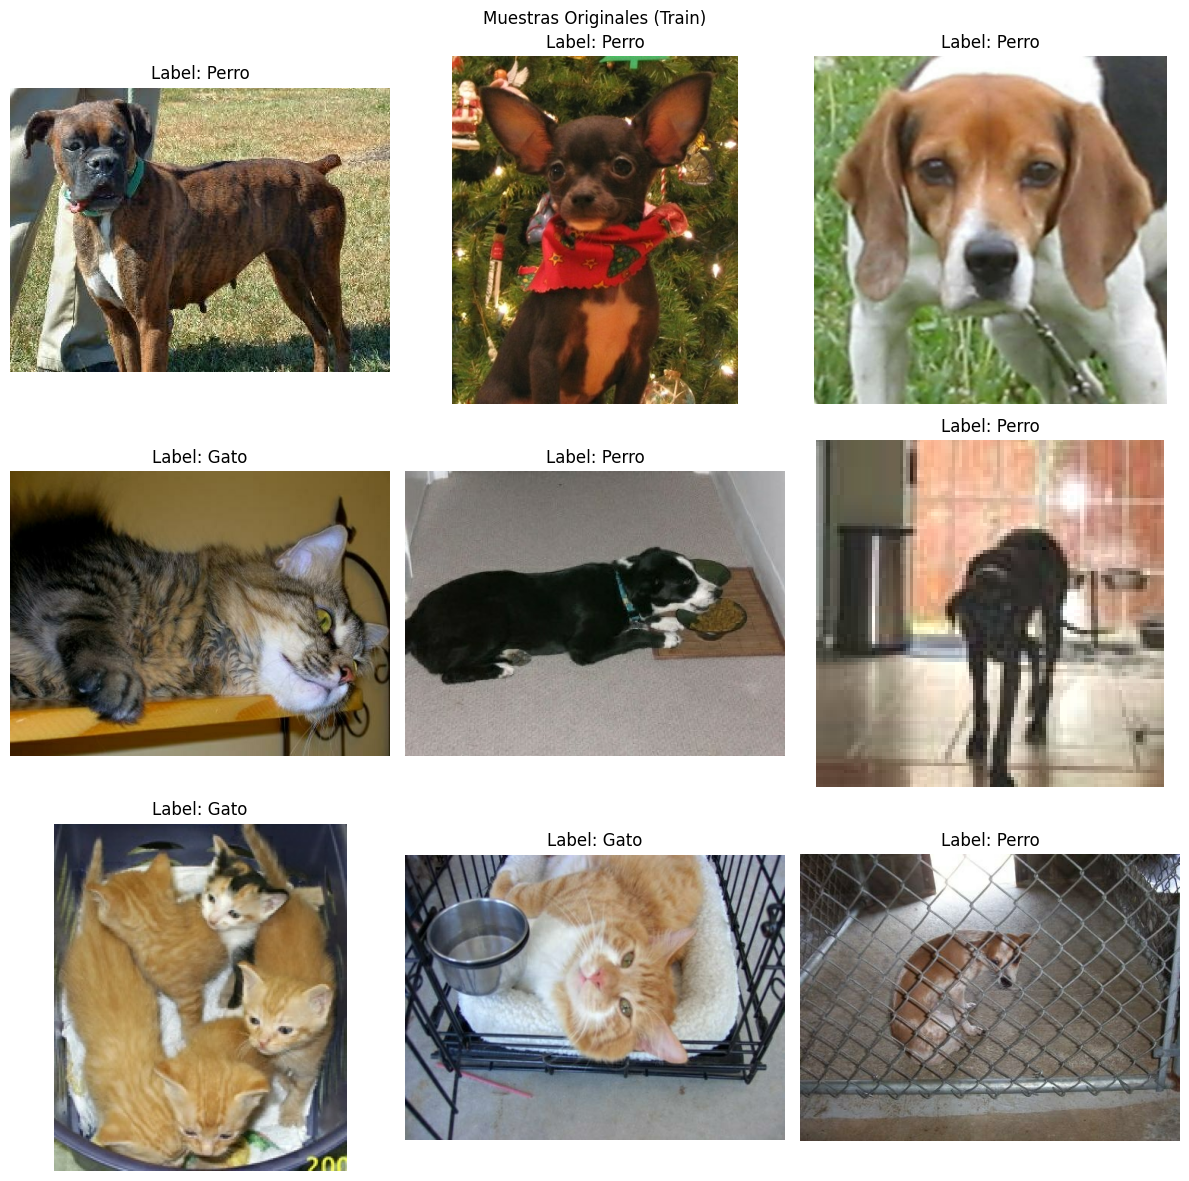

In [ ]:
print("\nVisualizando muestras originales...")
visualize_samples(ds_train, title="Muestras Originales (Train)")

## Preprocesamiento

Se aplican dos procesos fundamentales a todas las imágenes. El primero es el **redimensionamiento**, que asegura que todas las imágenes tengan el mismo tamaño. El segundo es la **normalización**, que ajusta los valores de píxeles para que cada canal de color se encuentre en el rango de 0 a 1.

Es importante distinguir entre el preprocesamiento y el aumento de datos:
* **Preprocesamiento** (redimensionamiento y normalización): Se aplica siempre, tanto en entrenamiento como en validación y prueba.
* **Aumento de datos** (RandomFlip, RandomRotation, etc.): Se aplica solo durante el entrenamiento.

El preprocesamiento puede implementarse mediante capas como `Resizing` y `Rescaling`, mientras que el aumento se realiza con las capas mencionadas anteriormente.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Aplicar aumento de datos SOLO al conjunto de entrenamiento
# NOTA: El aumento excesivo puede causar sobreajuste
train_dataset = ds_train.map(augment_image)  # Aumento de datos
train_dataset = train_dataset.map(lambda x, y: format_image(x, y, IMG_SIZE))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validación y test SIN aumento de datos
val_dataset = ds_val.map(lambda x, y: format_image(x, y, IMG_SIZE))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = ds_test.map(lambda x, y: format_image(x, y, IMG_SIZE))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Visualizando imágenes después del preprocesamiento...


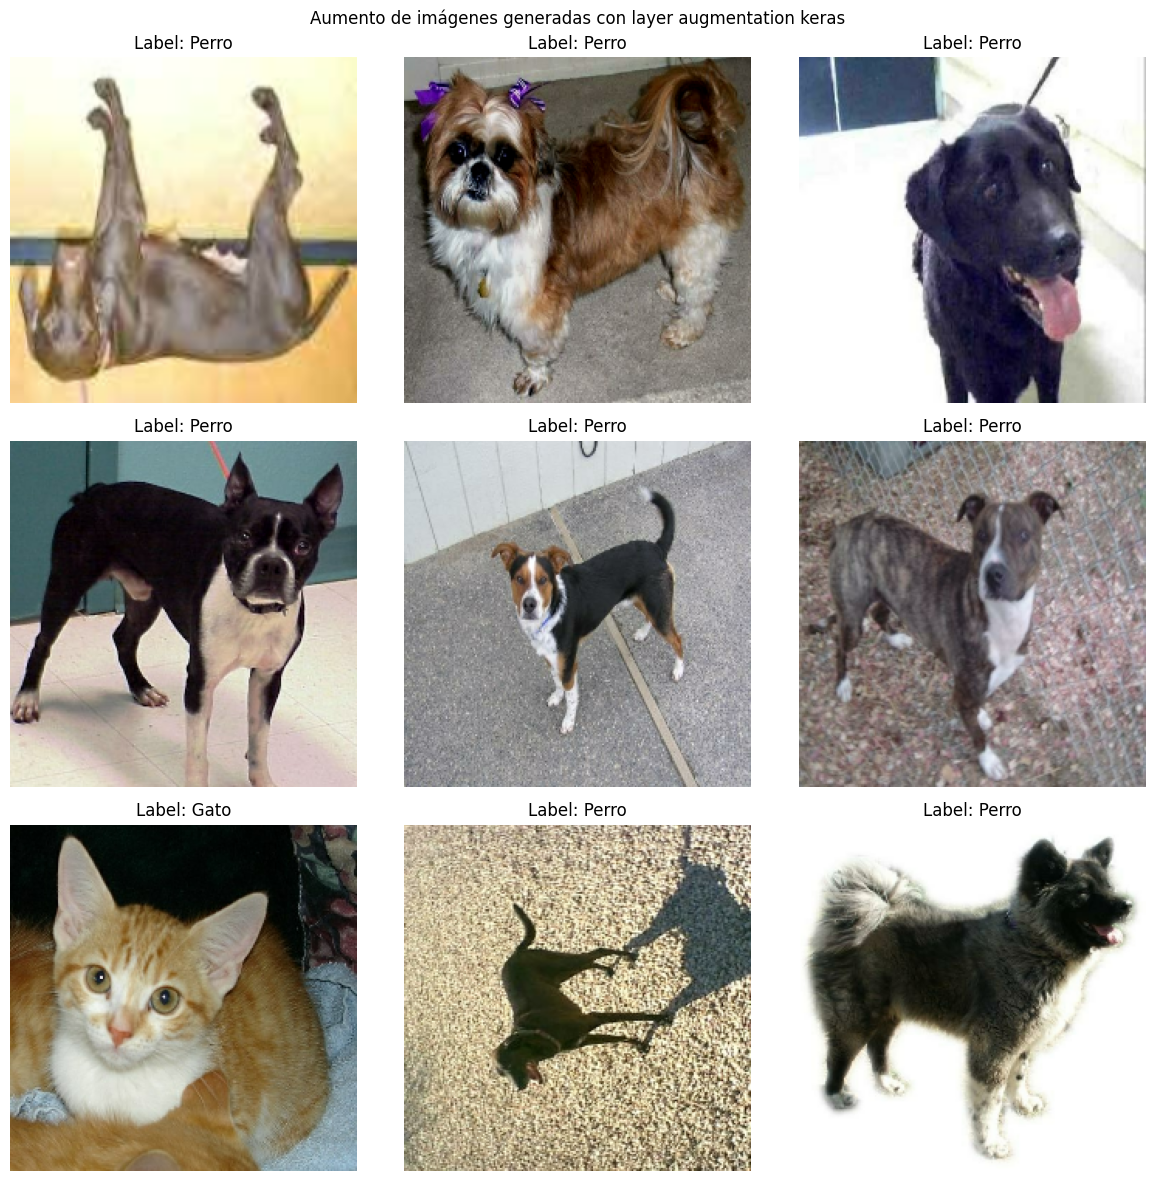

In [ ]:
# Visualizar después del preprocesamiento
print("\nVisualizando imágenes después del preprocesamiento...")
sample_batch = next(iter(train_dataset))
plt.figure(figsize=(12, 12))
for i in range(min(9, BATCH_SIZE)):
    ax = plt.subplot(3, 3, i + 1)
    # Desnormalizar para visualización
    img = (sample_batch[0][i].numpy() + 1) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    plt.imshow(img)

    txt_label = "Gato" if sample_batch[1][i].numpy() == 0 else "Perro"
    plt.title(f"Label: {txt_label}")
    plt.axis("off")
plt.suptitle("Aumento de imágenes generadas con layer augmentation keras")
plt.tight_layout()
plt.show()

## ***Transfer learning***

El *transfer learning* es una técnica que transfiere el conocimiento aprendido por un modelo en un problema previo a otro problema similar. Generalmente, se logra congelando las capas del modelo preentrenado (para conservar las características generales aprendidas) y añadiendo o modificando únicamente las últimas capas para adaptarlas a la nueva tarea. Una ventaja importante de esta técnica es el ahorro de tiempo de entrenamiento y la reducción de los recursos computacionales requeridos, en comparación con entrenar un modelo desde cero.

In [ ]:
# Crear modelo base
model, base_model = create_base_model(num_classes=2, freeze_layers=True)

# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # LR bajo
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks para evitar sobreajuste
callbacks = [
    # Early stopping: Detener si no mejora después de 10 épocas
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    # Reduce learning rate en plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),

    # Checkpoint para guardar el mejor modelo
    tf.keras.callbacks.ModelCheckpoint(
        'best_transfer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

Capas base congeladas para Transfer Learning


In [ ]:
# Resumen del modelo
print("\nResumen del modelo:")
model.summary()


Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,105 (3.86 MB)

 Trainable params: 73,985 (289.00 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# Entrenar modelo base
print("\nEntrenando modelo base...")
history_base = model.fit(
    train_dataset,
    epochs=10,  # Número limitado de épocas
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)


Entrenando modelo base...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 105s 150ms/step - accuracy: 0.5255 - loss: 1.8099 - val_accuracy: 0.5215 - val_loss: 1.1842 - learning_rate: 1.0000e-04
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 65s 106ms/step - accuracy: 0.5492 - loss: 0.9809 - val_accuracy: 0.5748 - val_loss: 0.8369 - learning_rate: 1.0000e-04
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - accuracy: 0.5607 - loss: 0.8002 - val_accuracy: 0.5752 - val_loss: 0.7515 - learning_rate: 1.0000e-04
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.5710 - loss: 0.7450 - val_accuracy: 0.6251 - val_loss: 0.7164 - learning_rate: 1.0000e-04
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.5740 - loss: 0.7224 - val_accuracy: 0.6234 - val_loss: 0.6987 - learning_rate: 1.0000e-04
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 64s 104ms/step - accuracy: 0.5749 - loss: 0.7093 - val_accuracy: 0.6371 - val_loss: 0.6889 - learning_rate: 1.0000e-04
Epoch 7/10
582/582

In [ ]:
# ==============================
# EVALUACIÓN DEL MODELO BASE
# ==============================
print("\nEvaluando modelo base en test...")
test_loss_base, test_accuracy_base = model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy (Base): {test_accuracy_base:.4f}")
print(f"Test Loss (Base): {test_loss_base:.4f}")


Evaluando modelo base en test...
Test Accuracy (Base): 0.6384
Test Loss (Base): 0.6705


## ***Fine-tuning***

Para llevar a cabo el *fine-tuning* también se requiere un modelo preentrenado que resuelva un problema similar al que se desea resolver. La principal ventaja del *fine-tuning* es el ahorro de recursos computacionales y tiempo, ya que se evita el entrenamiento desde cero.

Para aplicar *fine-tuning* se deben congelar algunas capas iniciales del modelo preentrenado (las que capturan características generales) y reentrenar las capas más profundas (las que aprenden características específicas). El número óptimo de capas a congelar depende del tamaño del dataset y la similitud entre la tarea original y la nueva, por lo que se recomienda experimentar con diferentes configuraciones.

In [ ]:
# Descongelar capas superiores del modelo base para fine tuning
base_model.trainable = True

In [ ]:
# IMPORTANTE: Congelar primeras capas, descongelar solo las últimas
# Esto previene el sobreajuste al no reentrenar todo el modelo
for layer in base_model.layers[:100]:  # Ajusta este número
    layer.trainable = False

print(f"Número de capas entrenables: {len([l for l in base_model.layers if l.trainable])}")

Número de capas entrenables: 57


In [ ]:
# Recompilar con learning rate más bajo para fine tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR muy bajo
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Nuevos callbacks para fine-tuning
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,  # Menos paciencia para fine tuning
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_finetuned_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max' # Sobreescribe el mejor modelo que maximiza el valor de val_accuracy
    )
]

In [ ]:
print("\nEntrenando con Fine Tuning...")
history_ft = model.fit(
    train_dataset,
    epochs=10,  # Menos épocas para fine-tuning
    validation_data=val_dataset,
    callbacks=callbacks_ft,
    verbose=1
)


Entrenando con Fine Tuning...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 113s 148ms/step - accuracy: 0.6176 - loss: 0.6662 - val_accuracy: 0.5322 - val_loss: 0.7313
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 67s 110ms/step - accuracy: 0.6881 - loss: 0.6074 - val_accuracy: 0.5245 - val_loss: 0.9402
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.7199 - loss: 0.5654 - val_accuracy: 0.5279 - val_loss: 1.0025
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 68s 110ms/step - accuracy: 0.7402 - loss: 0.5395 - val_accuracy: 0.5516 - val_loss: 0.8104
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/step - accuracy: 0.7537 - loss: 0.5181 - val_accuracy: 0.6625 - val_loss: 0.6107
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.7659 - loss: 0.5005 - val_accuracy: 0.7562 - val_loss: 0.5177
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - accuracy: 0.7743 - loss: 0.4885 - val_accuracy: 0.7820 - val_loss: 0.4717
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 109ms/s

## Evaluación del modelo después de *fine-tuning*

In [ ]:
print("\nEvaluando modelo después de fine-tuning...")
test_loss_ft, test_accuracy_ft = model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy (Fine Tuned): {test_accuracy_ft:.4f}")
print(f"Test Loss (Fine Tuned): {test_loss_ft:.4f}")


Evaluando modelo después de fine-tuning...
Test Accuracy (Fine Tuned): 0.8340
Test Loss (Fine Tuned): 0.3980


## Visualización de resultados

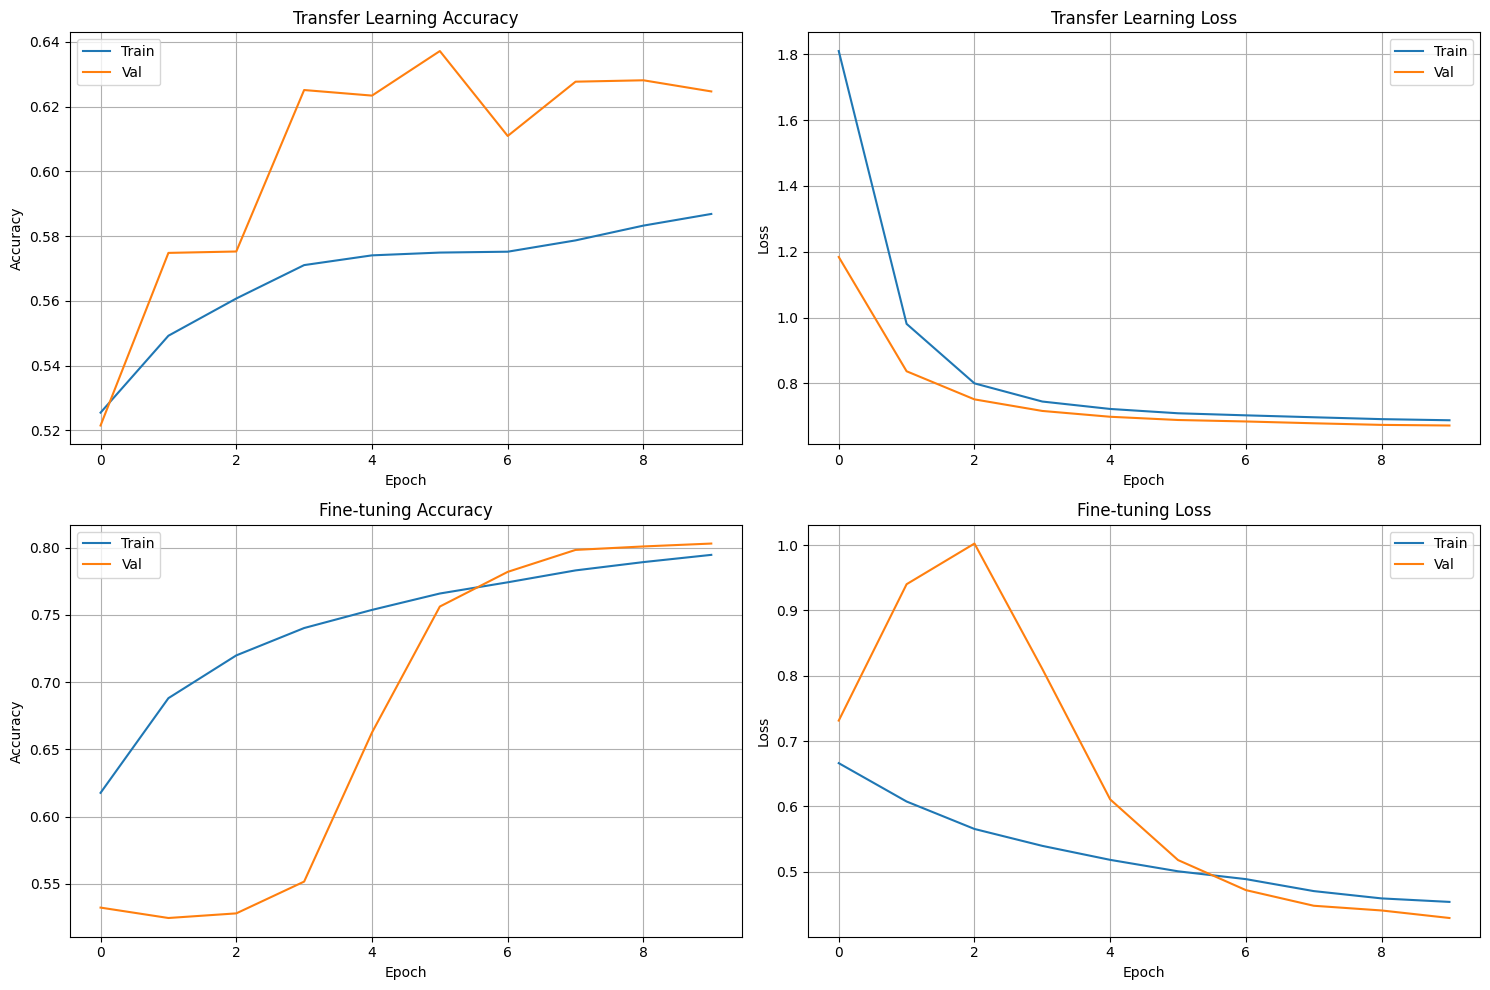

In [ ]:
def plot_history(history_base, history_ft):
    """Visualizar historial de entrenamiento"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy Transfer Learning
    axes[0, 0].plot(history_base.history['accuracy'], label='Train')
    axes[0, 0].plot(history_base.history['val_accuracy'], label='Val')
    axes[0, 0].set_title('Transfer Learning Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Loss Transfer Learning
    axes[0, 1].plot(history_base.history['loss'], label='Train')
    axes[0, 1].plot(history_base.history['val_loss'], label='Val')
    axes[0, 1].set_title('Transfer Learning Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Accuracy Fine Tuning
    axes[1, 0].plot(history_ft.history['accuracy'], label='Train')
    axes[1, 0].plot(history_ft.history['val_accuracy'], label='Val')
    axes[1, 0].set_title('Fine-tuning Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Loss Fine Tuning
    axes[1, 1].plot(history_ft.history['loss'], label='Train')
    axes[1, 1].plot(history_ft.history['val_loss'], label='Val')
    axes[1, 1].set_title('Fine-tuning Loss')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_base, history_ft)


Visualizando predicciones...


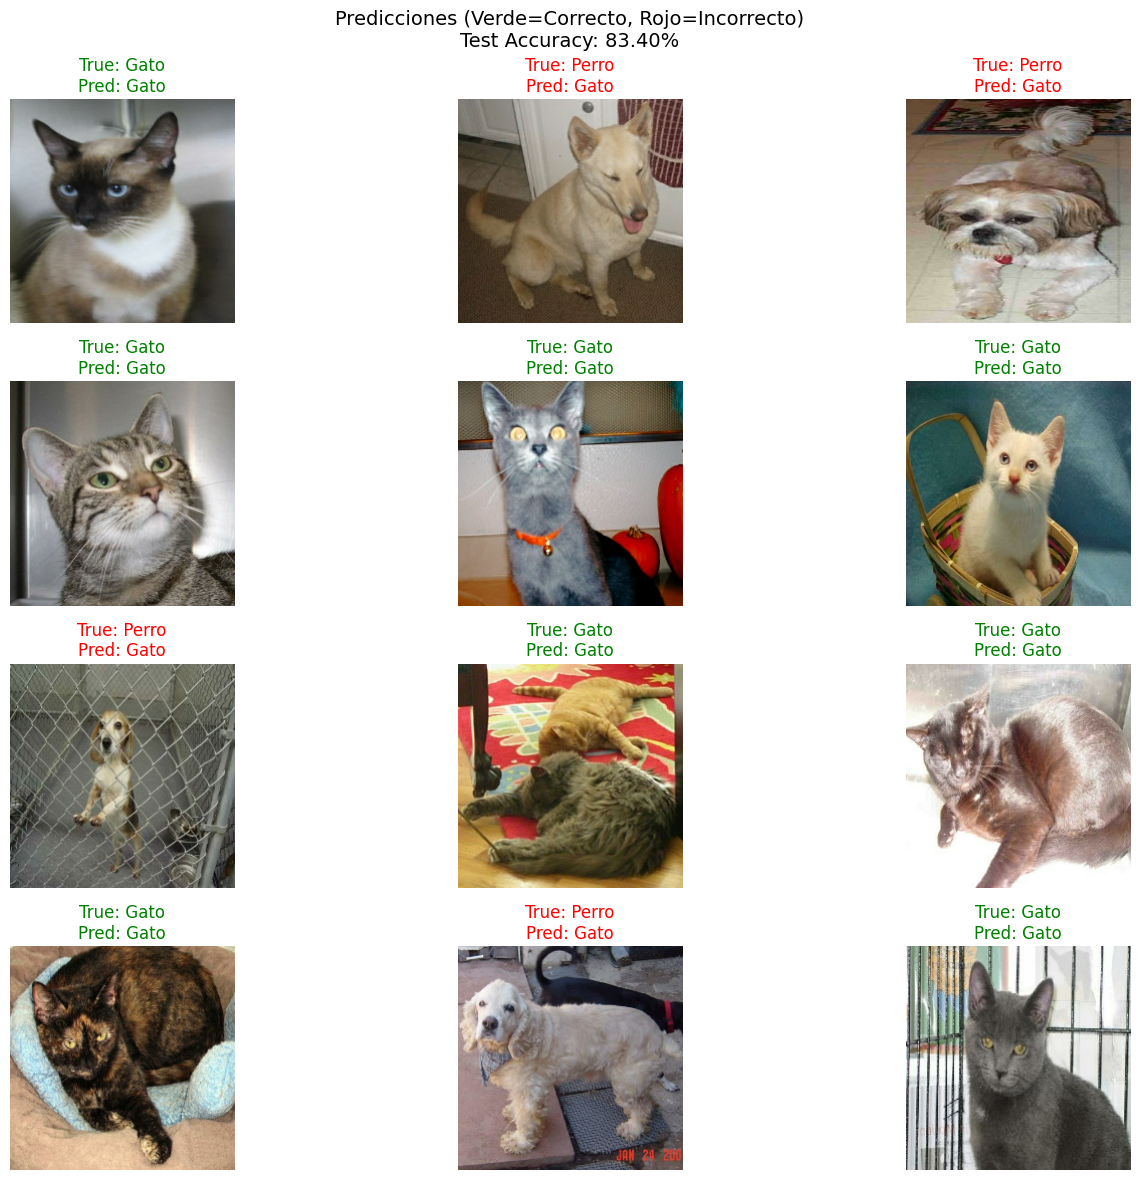

Accuracy en batch de muestra: 68.75%


In [ ]:
print("\nVisualizando predicciones...")
predict_and_visualize(model, test_dataset)

In [ ]:
def analyze_overfitting(history_base, history_ft):
    """Analizar indicadores de sobreajuste"""
    print("\n" + "="*50)
    print("ANÁLISIS DE SOBREAJUSTE")
    print("="*50)

    # Para transfer learning
    train_acc_base = history_base.history['accuracy'][-1]
    val_acc_base = history_base.history['val_accuracy'][-1]
    gap_base = train_acc_base - val_acc_base

    print(f"\nTransfer Learning:")
    print(f"Train Accuracy: {train_acc_base:.4f}")
    print(f"Val Accuracy: {val_acc_base:.4f}")
    print(f"Diferencia (Train-Val): {gap_base:.4f}")

    if gap_base > 0.1:
        print("POSIBLE SOBREAJUSTE EN TRANSFER LEARNING")

    # Para fine tuning
    train_acc_ft = history_ft.history['accuracy'][-1]
    val_acc_ft = history_ft.history['val_accuracy'][-1]
    gap_ft = train_acc_ft - val_acc_ft

    print(f"\nFine Tuning:")
    print(f"Train Accuracy: {train_acc_ft:.4f}")
    print(f"Val Accuracy: {val_acc_ft:.4f}")
    print(f"Diferencia (Train-Val): {gap_ft:.4f}")

    if gap_ft > 0.15:
        print("POSIBLE SOBREAJUSTE EN FINE TUNING")

    # Comparar con accuracy en test
    print(f"\nComparación con Test Set:")
    print(f"Test Accuracy Base: {test_accuracy_base:.4f}")
    print(f"Test Accuracy FT: {test_accuracy_ft:.4f}")
    print(f"Mejora: {(test_accuracy_ft - test_accuracy_base):.4f}")

analyze_overfitting(history_base, history_ft)


ANÁLISIS DE SOBREAJUSTE

Transfer Learning:
Train Accuracy: 0.5868
Val Accuracy: 0.6247
Diferencia (Train-Val): -0.0378

Fine Tuning:
Train Accuracy: 0.7947
Val Accuracy: 0.8031
Diferencia (Train-Val): -0.0084

Comparación con Test Set:
Test Accuracy Base: 0.6384
Test Accuracy FT: 0.8340
Mejora: 0.1956
